In [1]:
import IJulia
import Base64

# The julia kernel has built in support for Revise.jl, so this is the 
# recommended approach for long-running sessions:
# https://github.com/JuliaLang/IJulia.jl/blob/9b10fa9b879574bbf720f5285029e07758e50a5e/src/kernel.jl#L46-L51

# Users should enable revise within .julia/config/startup_ijulia.jl:
# https://timholy.github.io/Revise.jl/stable/config/#Using-Revise-automatically-within-Jupyter/IJulia-1

# clear console history
IJulia.clear_history()

fig_width = 7
fig_height = 5
fig_format = :png
fig_dpi = 96

# no retina format type, use svg for high quality type/marks
if fig_format == :retina
  fig_format = :svg
elseif fig_format == :pdf
  fig_dpi = 96
  # Enable PDF support for IJulia
  IJulia.register_mime(MIME("application/pdf"))
end

# convert inches to pixels
fig_width = fig_width * fig_dpi
fig_height = fig_height * fig_dpi

# Intialize Plots w/ default fig width/height
try
  import Plots

  # Plots.jl doesn't support PDF output for versions < 1.28.1
  # so use png (if the DPI remains the default of 300 then set to 96)
  if (Plots._current_plots_version < v"1.28.1") & (fig_format == :pdf)
    Plots.gr(size=(fig_width, fig_height), fmt = :png, dpi = fig_dpi)
  else
    Plots.gr(size=(fig_width, fig_height), fmt = fig_format, dpi = fig_dpi)
  end
catch e
  # @warn "Plots init" exception=(e, catch_backtrace())
end

# Initialize CairoMakie with default fig width/height
try
  import CairoMakie

  # CairoMakie's display() in PDF format opens an interactive window
  # instead of saving to the ipynb file, so we don't do that.
  # https://github.com/quarto-dev/quarto-cli/issues/7548
  if fig_format == :pdf
    CairoMakie.activate!(type = "png")
  else
    CairoMakie.activate!(type = string(fig_format))
  end
  CairoMakie.update_theme!(resolution=(fig_width, fig_height))
catch e
    # @warn "CairoMakie init" exception=(e, catch_backtrace())
end
  
# Set run_path if specified
try
  run_path = "L3J1bi9tZWRpYS9hbGYvZGF0b3MvbWlzcmVwb3NpdG9yaW9zL2RvY2VuY2lhL2VjdWFjaW9uZXMtZGlmZXJlbmNpYWxlcy1wcmFjdGljYXMtanVsaWE="
  if !isempty(run_path)
    run_path = String(Base64.base64decode(run_path))
    cd(run_path)
  end
catch e
  @warn "Run path init:" exception=(e, catch_backtrace())
end


# emulate old Pkg.installed beahvior, see
# https://discourse.julialang.org/t/how-to-use-pkg-dependencies-instead-of-pkg-installed/36416/9
import Pkg
function isinstalled(pkg::String)
  any(x -> x.name == pkg && x.is_direct_dep, values(Pkg.dependencies()))
end

# ojs_define
if isinstalled("JSON") && isinstalled("DataFrames")
  import JSON, DataFrames
  global function ojs_define(; kwargs...)
    convert(x) = x
    convert(x::DataFrames.AbstractDataFrame) = Tables.rows(x)
    content = Dict("contents" => [Dict("name" => k, "value" => convert(v)) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
elseif isinstalled("JSON")
  import JSON
  global function ojs_define(; kwargs...)
    content = Dict("contents" => [Dict("name" => k, "value" => v) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
else
  global function ojs_define(; kwargs...)
    @warn "JSON package not available. Please install the JSON.jl package to use ojs_define."
  end
end


# don't return kernel dependencies (b/c Revise should take care of dependencies)
nothing


In [2]:
#| echo: false
#| include: false
packages = ["SymPyPythonCall", "Plots", "CairoMakie", "DifferentialEquations", "LaTeXStrings", "Roots"]

6-element Vector{String}:
 "SymPyPythonCall"
 "Plots"
 "CairoMakie"
 "DifferentialEquations"
 "LaTeXStrings"
 "Roots"

In [3]:
#| echo: false
#| include: false
using Plots, CairoMakie
# Plots y Makie generan además una representación text/html con la imagen en base64
# en una sola línea; con figuras grandes esa línea desborda la pila del conversor
# de Quarto a Markdown. La desactivamos y dejamos solo image/png.
Base.showable(::MIME"text/html", ::Plots.Plot) = false
Base.showable(::MIME"text/html", ::Makie.FigureLike) = false

In [4]:
#| echo: false
using Markdown
v = string(VERSION)
Markdown.parse("![](https://img.shields.io/badge/Julia-$(v)-9558B2?logo=julia)")

![](https://img.shields.io/badge/Julia-1.12.6-9558B2?logo=julia)


In [5]:
#| echo: false
using Markdown
v = string(VERSION)
Markdown.parse("**Versión de Julia:** $(v)")

**Versión de Julia:** 1.12.6


In [6]:
#| echo: false
#| include: false
import Pkg
active_project = Base.active_project()
global_env = joinpath(homedir(), ".julia", "environments", "v$(VERSION.major).$(VERSION.minor)", "Project.toml")
Pkg.activate(global_env)

  Activating project at `~/.julia/environments/v1.12`


In [7]:
#| echo: false
Pkg.status(packages)

Status `~/.julia/environments/v1.12/Project.toml`
⌃ [13f3f980] CairoMakie v0.15.9
  [0c46a032] DifferentialEquations v8.0.2
  [b964fa9f] LaTeXStrings v1.4.0
  [91a5bcdd] Plots v1.41.6
  [f2b01f46] Roots v3.0.6
  [bc8888f7] SymPyPythonCall v0.5.1
Info Packages marked with ⌃ have new versions available and may be upgradable.


In [8]:
#| echo: false
#| include: false
#Pkg.activate(active_project)

In [9]:
function campo_direcciones_plot(f, ts, ys; escala = 0.4, kwargs...)
    T = [t for y in ys for t in ts]
    Y = [y for y in ys for t in ts]
    V = f.(T, Y)
    r = (maximum(ts) - minimum(ts)) / (maximum(ys) - minimum(ys))  # Relación entre los rangos de los ejes.
    dx = escala / 2 ./ sqrt.(1 .+ (V .* r) .^ 2)  # Corregimos la pendiente con r para que todos los
    dy = V .* dx                                  # segmentos se vean del mismo tamaño en el gráfico.
    Xs = reduce(vcat, [[t - dxi, t + dxi, NaN] for (t, dxi) in zip(T, dx)])
    Ys = reduce(vcat, [[y - dyi, y + dyi, NaN] for (y, dyi) in zip(Y, dy)])
    Plots.plot(Xs, Ys, color = :gray, alpha = 0.7, label = ""; kwargs...)
end;

In [10]:
using CairoMakie
function campo_direcciones_makie!(ax, f, ts, ys; escala = 0.4, kwargs...)
    T = [t for y in ys for t in ts]
    Y = [y for y in ys for t in ts]
    V = f.(T, Y)
    r = (maximum(ts) - minimum(ts)) / (maximum(ys) - minimum(ys))  # Relación entre los rangos de los ejes.
    dx = escala / 2 ./ sqrt.(1 .+ (V .* r) .^ 2)  # Corregimos la pendiente con r para que todos los
    dy = V .* dx                                  # segmentos se vean del mismo tamaño en el gráfico.
    segs = reduce(vcat, [[Point2f(t - dxi, y - dyi), Point2f(t + dxi, y + dyi)]
                          for (t, y, dxi, dyi) in zip(T, Y, dx, dy)])
    Makie.linesegments!(ax, segs; color = (:gray, 0.7), kwargs...)
end;

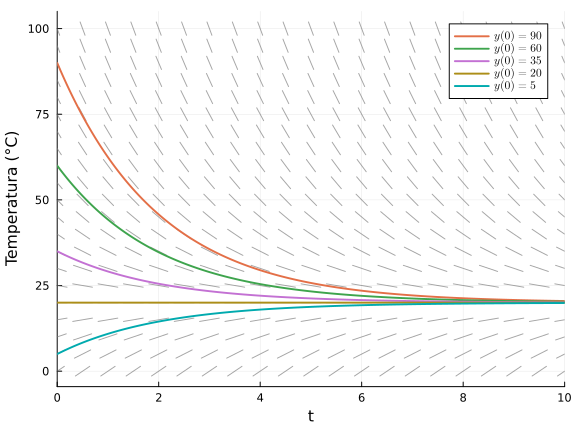

In [11]:
using Plots, DifferentialEquations
f(t, y) = -0.5 * (y - 20)
plt = campo_direcciones_plot(f, 0:0.5:10, 0:5:100,
    xlab = "Tiempo (min)", ylab = "Temperatura (°C)", legend = true, size = (600, 450))
# Curvas integrales para distintas temperaturas iniciales.
for y0 in [90, 60, 35, 20, 5]
    prob = ODEProblem((y, p, t) -> f(t, y), float(y0), (0.0, 10.0))
    sol = solve(prob)
    Plots.plot!(plt, sol, lw = 2, label = L"y(0)=%$y0")
end
plt

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/kJl0u/src/scenes.jl:264


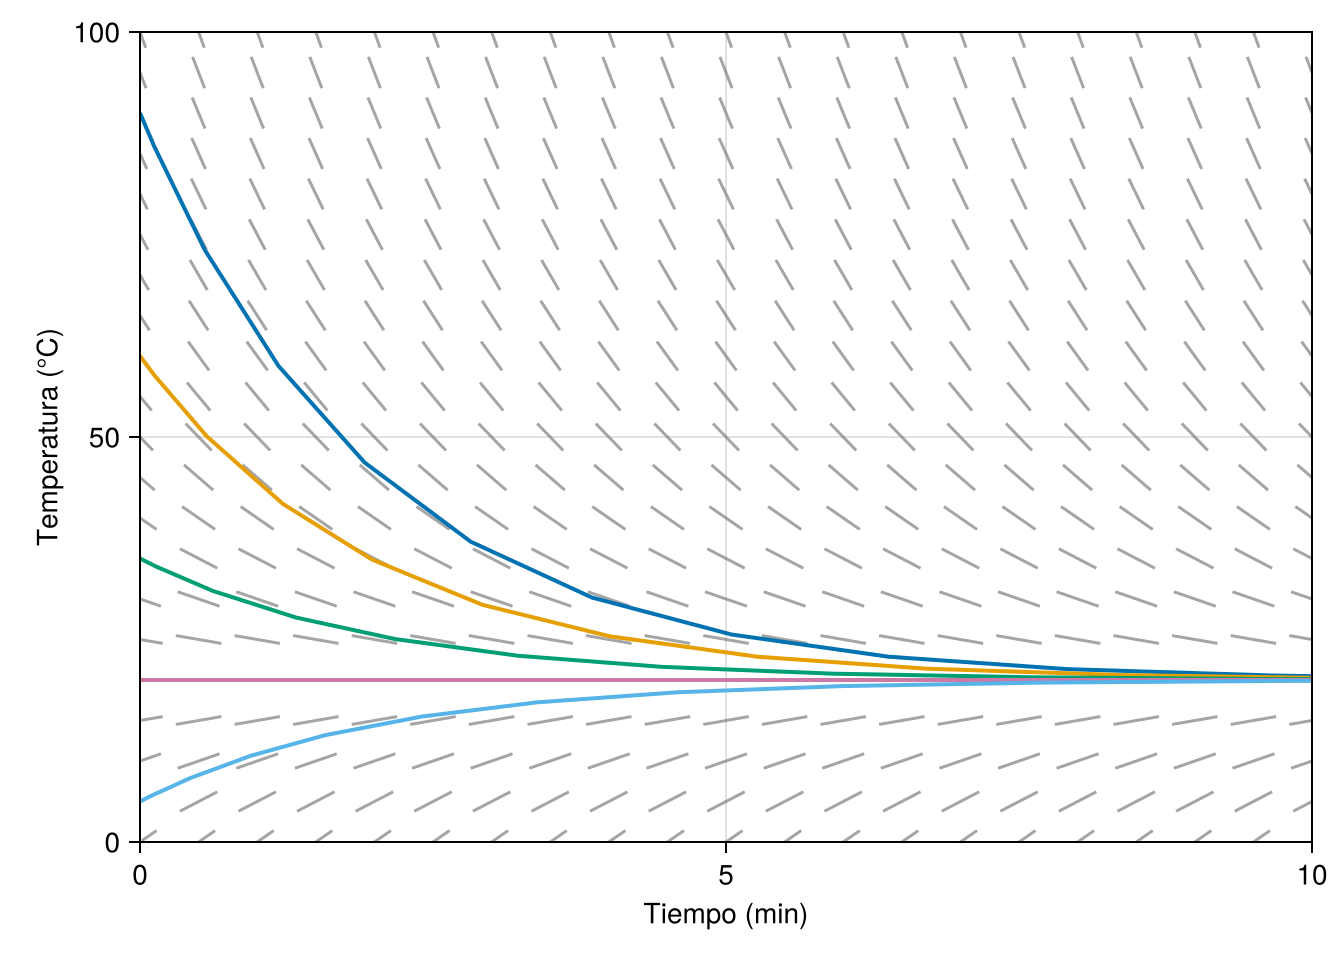

In [12]:
using CairoMakie, DifferentialEquations
f(t, y) = -0.5 * (y - 20)
fig = Figure()
ax = Axis(fig[1, 1], xlabel = "Tiempo (min)", ylabel = "Temperatura (°C)", limits = ((0, 10), (0, 100)))
campo_direcciones_makie!(ax, f, 0:0.5:10, 0:5:100, escala = 0.4)
# Curvas integrales para distintas temperaturas iniciales.
for y0 in [90, 60, 35, 20, 5]
prob = ODEProblem((y, p, t) -> f(t, y), float(y0), (0.0, 10.0))
sol = solve(prob)
Makie.lines!(ax, sol.t, sol.u, linewidth = 2, label = L"y(0)=%$y0")
end
fig

In [13]:
using SymPyPythonCall
@syms t y()
eq = Eq(diff(y(t), t), -1//2 * (y(t) - 20))
sol = dsolve(eq, y(t), ics = Dict(y(0) => 90))

                -t 
                ───
                 2 
y(t) = 20 + 70⋅ℯ   

In [14]:
t30 = solve(Eq(rhs(sol), 30), t)[1]
N(t30)

     y            
- y⋅ℯ  + 2⋅log(49)

In [15]:
using SymPyPythonCall
@syms u
fexpr = 0.4 * u * (1 - u / 10)
equilibrios = solve(fexpr, u)

2-element Vector{Sym{PythonCall.Py}}:
              0.0
 10.0000000000000

In [16]:
dfdu = diff(fexpr, u)
[(y0, dfdu(u => y0)) for y0 in equilibrios]

2-element Vector{Tuple{Sym{PythonCall.Py}, Sym{PythonCall.Py}}}:
 (0.0, 0.400000000000000)
 (10.0000000000000, -0.400000000000000)

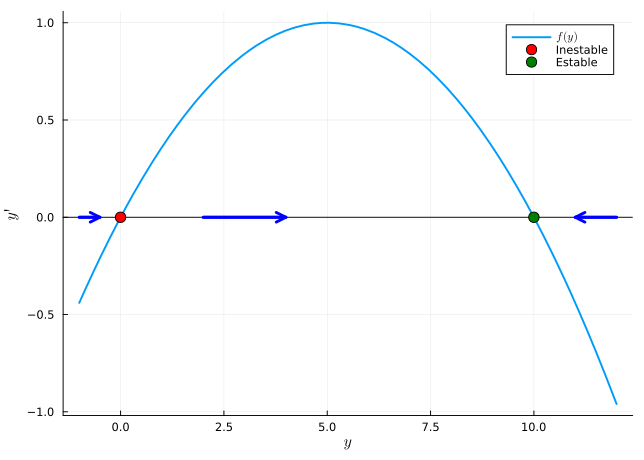

In [17]:
using Plots
fnum(y) = 0.4y * (1 - y / 10)
Plots.plot(fnum, -1, 12, lw = 2, label = L"f(y)", xlab = L"y", ylab = L"y'")
hline!([0], color = :black, label = "")
Plots.scatter!([0], [0], color = :red, ms = 6, label = "Inestable")
Plots.scatter!([10], [0], color = :green, ms = 6, label = "Estable")
# Flechas de la línea de fases sobre el eje horizontal.
Plots.plot!([2, 4], [0, 0], arrow = true, lw = 3, color = :blue, label = "")
Plots.plot!([12, 11], [0, 0], arrow = true, lw = 3, color = :blue, label = "")
Plots.plot!([-1, -0.5], [0, 0], arrow = :head, lw = 3, color = :blue, label = "")

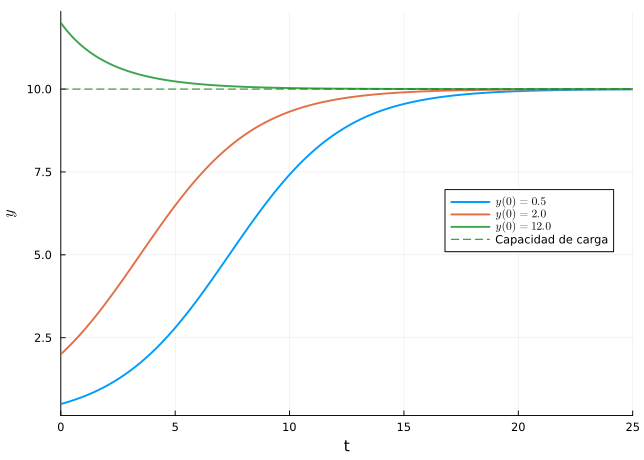

In [18]:
plt = Plots.plot(xlab = L"t", ylab = L"y", legend = :right)
for y0 in [0.5, 2.0, 12.0]
    prob = ODEProblem((y, p, t) -> fnum(y), y0, (0.0, 25.0))
    Plots.plot!(plt, solve(prob), lw = 2, label = L"y(0)=%$y0")
end
hline!(plt, [10], ls = :dash, color = :green, label = "Capacidad de carga")
plt

In [19]:
using SymPyPythonCall
@syms u h::positive
equilibrios = solve(0.4 * u * (1 - u / 10) - h, u)

2-element Vector{Sym{PythonCall.Py}}:
 5.0 - 5.0*sqrt(1.0 - h)
 5.0*sqrt(1.0 - h) + 5.0

In [20]:
hcrit = solve(1 - h, h)

1-element Vector{Sym{PythonCall.Py}}:
 1

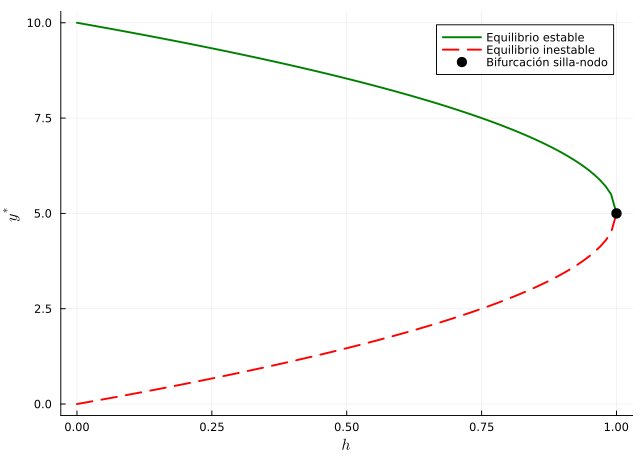

In [21]:
hs = 0:0.01:1
yplus  = 5 .+ 5 .* sqrt.(1 .- hs)
yminus = 5 .- 5 .* sqrt.(1 .- hs)
Plots.plot(hs, yplus, lw = 2, color = :green, label = "Equilibrio estable", xlab = L"h", ylab = L"y^*")
Plots.plot!(hs, yminus, lw = 2, ls = :dash, color = :red, label = "Equilibrio inestable")
Plots.scatter!([1], [5], color = :black, ms = 6, label = "Bifurcación silla-nodo")

In [22]:
@syms t y() λ::positive y0::positive
# Comprobación directa con dsolve:
sol = dsolve(Eq(diff(y(t), t), -λ * y(t)), y(t), ics = Dict(y(0) => y0))

           -t⋅λ
y(t) = y₀⋅ℯ    

In [23]:
λv = log(Sym(2)) / 5730
edad = solve(Eq(exp(-λv * t), Sym(53) / 100), t)[1]
N(edad)

              ⎛      5730 ⎞
              ⎜     ──────⎟
              ⎜     log(2)⎟
     y        ⎜⎛100⎞      ⎟
- y⋅ℯ  + 2⋅log⎜⎜───⎟      ⎟
              ⎝⎝53 ⎠      ⎠

In [24]:
using SymPyPythonCall
@syms x::positive y()
k, a = Sym(1)/5, 200
eq = Eq(diff(y(x), x), (y(x) - k * sqrt(x^2 + y(x)^2)) / x)
sol = dsolve(eq, y(x), ics = Dict(y(a) => 0))
simplify(rhs(sol))

       ⎛log(x)   log(200)⎞
-x⋅sinh⎜────── - ────────⎟
       ⎝  5         5    ⎠

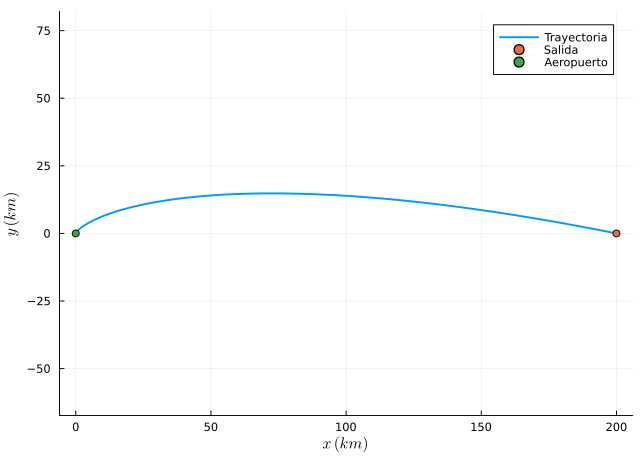

In [25]:
traj(x) = 100 * ((x / 200)^0.8 - (x / 200)^1.2)
Plots.plot(traj, 0, 200, lw = 2, label = "Trayectoria", aspect_ratio = :equal, xlab = L"x \; (km)", ylab = L"y \; (km)")
Plots.scatter!([200], [0], label = "Salida"); Plots.scatter!([0], [0], label = "Aeropuerto")

In [26]:
using Roots
# Máxima desviación:
xmax = find_zero(x -> 0.8 * (x/200)^(-0.2) - 1.2 * (x/200)^0.2, 100) / 200 |> 
        u -> 200u
(xmax, traj(xmax))

(72.57747386024232, 14.814814814814808)

In [27]:
using SymPyPythonCall
@syms x y
M = x^3 - 2x * y
N = y - x^2
diff(M, y) == diff(N, x)

true

In [28]:
F = integrate(M, x)          # F = x⁴/4 − x²y + g(y)
g = integrate(N - diff(F, y), y)
F = F + g

 4           2
x     2     y 
── - x ⋅y + ──
4           2 

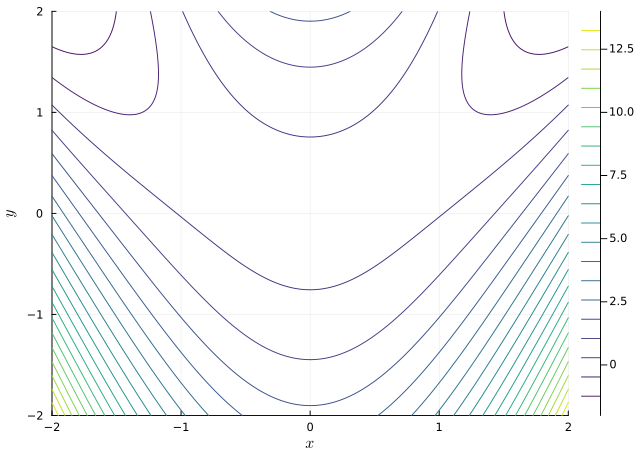

In [29]:
Fnum(x, y) = x^4 / 4 - x^2 * y + y^2 / 2
xs = ys = range(-2, 2, length = 300)
Plots.contour(xs, ys, Fnum, levels = 20, xlab = L"x", ylab = L"y",
        color = :viridis, cbar = true)

In [30]:
@syms x y
M = y
N = 2x - y * exp(y)
cociente = simplify((diff(N, x) - diff(M, y)) / M)

1
─
y

In [31]:
μ = exp(integrate(cociente, y))

y

In [32]:
M2, N2 = μ * M, μ * N
diff(M2, y) == diff(N2, x)

true

In [33]:
F = integrate(M2, x)
F = F + integrate(N2 - diff(F, y), y) |> simplify

   2   ⎛   2          ⎞  y
x⋅y  + ⎝- y  + 2⋅y - 2⎠⋅ℯ 

In [34]:
@syms t x()
sol = dsolve(Eq(diff(x(t), t), (t * exp(t) - 2x(t)) / t), x(t))
simplify(rhs(sol))

      2  t        t      t
C₁ + t ⋅ℯ  - 2⋅t⋅ℯ  + 2⋅ℯ 
──────────────────────────
             2            
            t             

In [35]:
using SymPyPythonCall
@syms t q()
eq = Eq(diff(q(t), t) + 10 * q(t), Sym(12)/1000 * cos(10t))
sol = dsolve(eq, q(t), ics = Dict(q(0) => 0))
qsol = simplify(rhs(sol))

        ⎛       π⎞           
3⋅√2⋅sin⎜10⋅t + ─⎟      -10⋅t
        ⎝       4⎠   3⋅ℯ     
────────────────── - ────────
       5000            5000  

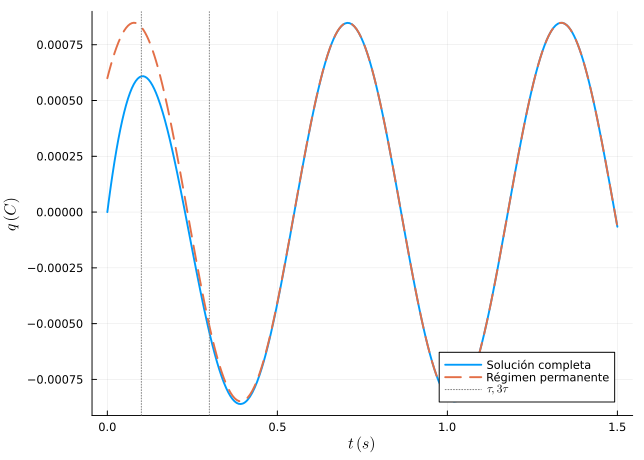

In [36]:
qnum = lambdify(qsol, (t,))
qperm(t) = 0.0006 * (cos(10t) + sin(10t))
Plots.plot(qnum, 0, 1.5, lw = 2, label = "Solución completa",
    xlab = L"t \; (s)", ylab = L"q \; (C)")
Plots.plot!(qperm, 0, 1.5, ls = :dash, lw = 2, label = "Régimen permanente")
vline!([0.1, 0.3], color = :gray, ls = :dot, label = L"\tau, 3\tau")

In [37]:
using SymPyPythonCall
@syms t A()
sol = dsolve(Eq(diff(A(t), t), Sym(5)/100 * A(t) + 6000), A(t), ics = Dict(A(0) => 10000))

               t          
               ──         
               20         
A(t) = 130000⋅ℯ   - 120000

In [38]:
A30 = N(rhs(sol)(t => 30))

     y                    3/2
- y⋅ℯ  - 240000 + 260000⋅ℯ   

In [39]:
@syms d::positive
solA = dsolve(Eq(diff(A(t), t), Sym(5)/100 * A(t) + d), A(t), ics = Dict(A(0) => 10000))
dreq = solve(Eq(rhs(solA)(t => 30), 1000000), d)[1]

    ⎛        3/2⎞
500⋅⎝-100 + ℯ   ⎠
─────────────────
         3/2     
    1 - ℯ        

In [40]:
@syms x y()
sol = dsolve(Eq(diff(y(x), x), 2x * y(x) / (x^2 - y(x)^2)), y(x))

2-element Vector{Sym{PythonCall.Py}}:
 Eq(y(x), -sqrt(-4*x^2 + exp(2*C1))/2 + exp(C1)/2)
  Eq(y(x), sqrt(-4*x^2 + exp(2*C1))/2 + exp(C1)/2)

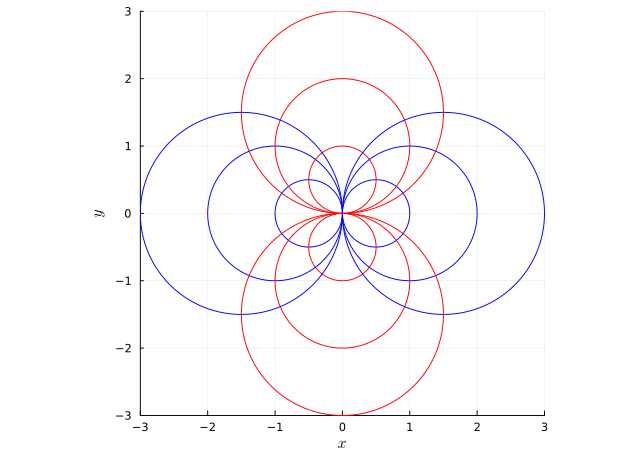

In [41]:
plt = Plots.plot(aspect_ratio = :equal, legend = false, xlab = L"x", ylab = L"y", xlims = (-3, 3), ylims = (-3, 3))
θ = range(0, 2π, length = 200)
for c in [0.5, 1, 1.5]
    Plots.plot!(plt, c .+ c .* cos.(θ),  c .* sin.(θ), color = :blue)   # Equipotenciales
    Plots.plot!(plt, -c .+ c .* cos.(θ), c .* sin.(θ), color = :blue)
    Plots.plot!(plt, c .* cos.(θ),  c .+ c .* sin.(θ), color = :red)    # Líneas de campo
    Plots.plot!(plt, c .* cos.(θ), -c .+ c .* sin.(θ), color = :red)
end
plt